/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-23 16:22:17,273 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-23 16:22:17,956 INFO Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.
2025-06-23 16:22:17,956 | INFO     | tic.data.xenium.loader | Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.


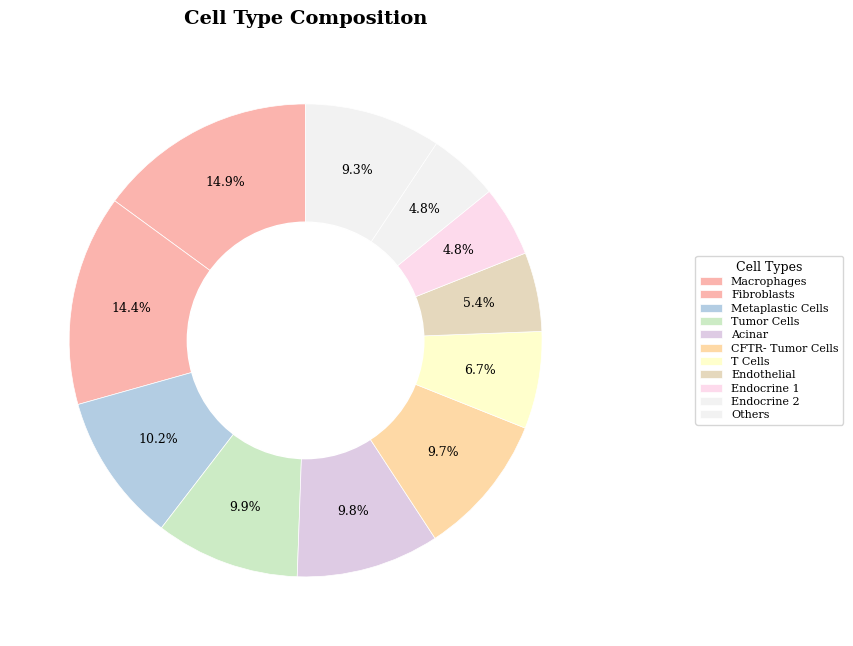

In [1]:
from tic.data import load_xenium_dataset

pancreas_adata = load_xenium_dataset(
    name='xenium_pancreas_cancer',
)

pancreas_adata

from tic.plotting.statistics import plot_cell_type_pie_nature

plot_cell_type_pie_nature(pancreas_adata.obs['cell_type'].value_counts())

In [2]:
tumor_mask = pancreas_adata.obs['cell_type'].str.lower().str.contains("tumor")
tumor_adata = pancreas_adata[tumor_mask].copy()
print(tumor_adata.obs['cell_type'].value_counts())

cell_type
Tumor Cells          18847
CFTR- Tumor Cells    18592
Name: count, dtype: int64


In [6]:
from tic.annotation.api import annotate_emt_state
from tic.constant import EPITHELIAL_GENES, MESENCHYMAL_GENES

tumor_adata = annotate_emt_state(adata=tumor_adata, epithelial_genes=EPITHELIAL_GENES,mesenchymal_genes=MESENCHYMAL_GENES, cluster_on='index')

tumor_adata.obs.head()

,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,group,cell_type,epi_score,mes_score,emt_index,emt_progress,emt_label
aabnffhk-1,2480.915283,681.721863,130,0,0,0,0,130,65.476565,43.259689,Tumor Cells,Tumor Cells,-0.976190,-0.095238,0.880952,0.475000,Mesenchymal
aabpebkp-1,2469.907227,685.289429,200,0,0,0,0,200,141.429380,59.606252,CFTR- Tumor Cells,CFTR- Tumor Cells,0.452381,-0.095238,-0.547619,0.381250,Epithelial
aacaccna-1,2484.630615,687.143555,67,0,0,0,0,67,47.639845,27.635626,CFTR- Tumor Cells,CFTR- Tumor Cells,-0.142857,0.000000,0.142857,0.426563,Mesenchymal
aacbcimn-1,2477.419189,692.878479,171,0,0,0,0,171,75.140003,43.259689,CFTR- Tumor Cells,CFTR- Tumor Cells,0.738095,-0.047619,-0.785714,0.365625,Epithelial
aaccdkah-1,2467.606201,695.293945,188,0,0,0,0,188,115.870942,61.006096,CFTR- Tumor Cells,CFTR- Tumor Cells,-1.071429,-0.142857,0.928571,0.478125,Mesenchymal


In [ ]:
from tic.wrappers import FeatureWrapper

fw = FeatureWrapper(
    centre_types=['Tumor Cells','CFTR- Tumor Cells'],
)